# 🔥 Spatial Statistics & Geographic Modeling with Google Earth Engine
## **Project: Wildfire Risk Prediction in Chiang Mai**

**Course:** GE 234 Basic Programming for Geographers
**Instructor:** ผศ.ดร.สิทธิศักดิ์ หมูคำหล้า
**Thammasat University**

---

### Learning Objectives
1. เข้าใจ Tobler's First Law of Geography และ Spatial Autocorrelation
2. คำนวณ Moran's I เพื่อวัดรูปแบบเชิงพื้นที่
3. เติมข้อมูลที่หายไปด้วย focal_mean และ IDW
4. สร้าง Layer Stack จากข้อมูลหลายแหล่ง
5. ใช้ Random Forest ML ใน GEE เพื่อทำนายพื้นที่เสี่ยงไฟป่า
6. ประเมินความแม่นยำด้วย Confusion Matrix, Overall Accuracy, และ Kappa

### Workflow Overview
```
Spatial Statistics → Gap Filling → Layer Stacking → ML Classification → Accuracy Assessment
     Part 1                              Part 2
```


## 🛠️ Section 0: Setup & Authentication

ติดตั้ง library และเชื่อมต่อ Google Earth Engine


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 0 — ติดตั้ง Library และเชื่อมต่อ Google Earth Engine
# ════════════════════════════════════════════════════════════
# ทำครั้งเดียวต่อ session (ถ้า runtime ยังอยู่ไม่ต้อง run ซ้ำ)

!pip install geemap earthengine-api pysal libpysal esda splot folium branca -q
# geemap        → wrapper สำหรับแสดง GEE map ใน Colab/Jupyter
# earthengine-api → คุยกับ Google Earth Engine cloud
# pysal / libpysal / esda / splot → spatial statistics (Moran's I, LISA)
# folium / branca → interactive map บน basemap จริง

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Authentication ──────────────────────────────────────────
# ครั้งแรกจะ popup ให้ login Google Account
# หลังจากนั้น token จะถูก cache ไว้ใน Colab session
ee.Authenticate()

# ── Initialize พร้อมระบุ Project ─────────────────────────────
# ต้องสร้าง GEE Project ก่อนที่ https://code.earthengine.google.com
# แล้วใส่ชื่อ Project ID ตรงนี้
ee.Initialize(project='ee-pythoncolab-418913')  # <-- เปลี่ยนเป็น Project ID ของตัวเอง

print("✅ Google Earth Engine initialized successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.6 MB/s eta 0:00:00
✅ Google Earth Engine initialized successfully!


---
# 📊 Part 1: Spatial Statistics Fundamentals

## เนื้อหาที่จะเรียน
- Tobler's First Law of Geography
- Spatial Autocorrelation
- Moran's I
- การเติมข้อมูลที่หายไป (Gap Filling)


## 1.1 Tobler's First Law of Geography

> "Everything is related to everything else, but near things are more related than distant things."
> — Waldo Tobler, 1970

### ความหมายในบริบทไฟป่า
- พื้นที่ใกล้กันมีแนวโน้มจะมีสภาพแวดล้อมคล้ายกัน (อุณหภูมิ, ความชื้น, พืชพรรณ)
- ถ้าจุดหนึ่งเกิดไฟป่า → พื้นที่ใกล้เคียงก็มีความเสี่ยงสูงด้วย
- นี่คือพื้นฐานของ **Spatial Autocorrelation**


/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/1815266460.py:33: UserWarning: Glyph 3655 (\N{THAI CHARACTER MAITAIKHU}) missing from font(s) DejaVu Sans.
  pl

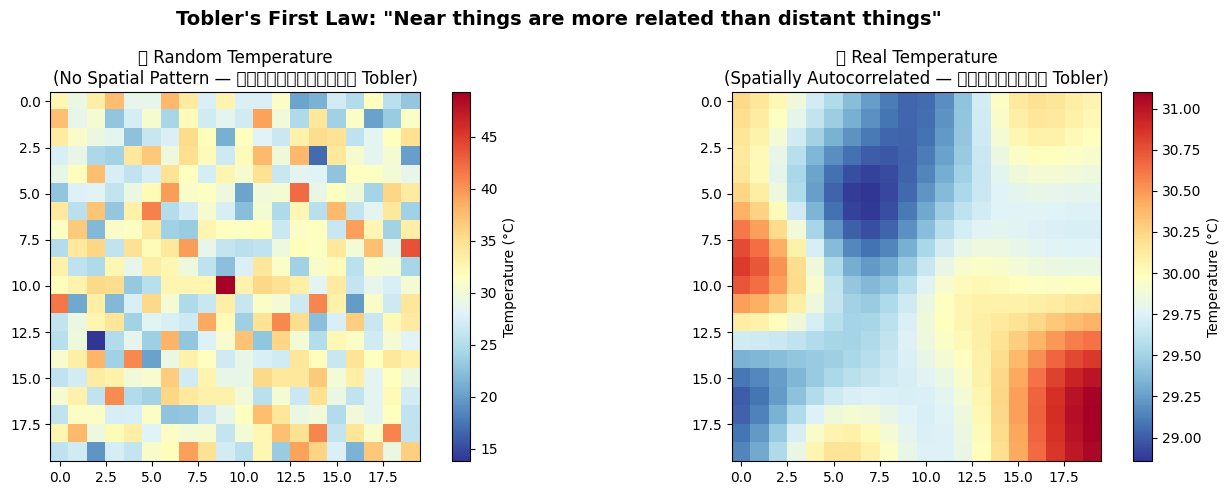

ซ้าย  : Random — แต่ละ pixel อิสระต่อกัน ไม่มี spatial pattern
ขวา  : Real-world — pixel ใกล้กัน → ค่าใกล้กัน (Tobler's Law)

→ Implication: ถ้าเราวัด fire risk ที่จุดหนึ่ง
  จุดที่อยู่ใกล้ ๆ ควรมี risk ใกล้เคียงกัน
  นี่คือหลักการเบื้องหลัง spatial interpolation ทั้งหมด


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.1 — Tobler's First Law: เปรียบเทียบ Random vs Spatial
# ════════════════════════════════════════════════════════════
# แนวคิด: ถ้าโลกจริงเป็นแบบ Tobler → pixel ที่อยู่ใกล้กันจะมีค่าใกล้เคียงกัน
#          ถ้าสุ่มแบบ random → ไม่มี pattern เลย

from scipy.ndimage import gaussian_filter
np.random.seed(42)

# สร้างข้อมูลอุณหภูมิจำลอง 2 แบบ
# ─── แบบที่ 1: Random ──────────────────────────────────────
# randn(20,20) → noise สุ่มล้วน ๆ แต่ละ cell เป็นอิสระต่อกัน
random_temp = np.random.randn(20, 20) * 5 + 30   # mean 30°C, std 5

# ─── แบบที่ 2: Spatially Autocorrelated ────────────────────
# gaussian_filter คือ "blur" → ทำให้ค่าของ pixel ใกล้เคียงกัน
# sigma=3 คือ "ระยะอิทธิพล" ยิ่งมาก ยิ่ง smooth = ยิ่งเห็น pattern ชัด
random_field = np.random.randn(20, 20)
temperature  = gaussian_filter(random_field, sigma=3) * 5 + 30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(random_temp, cmap='RdYlBu_r')
axes[0].set_title('❌ Random Temperature\n(No Spatial Pattern — ไม่เป็นไปตาม Tobler)', fontsize=12)
plt.colorbar(im1, ax=axes[0], label='Temperature (°C)')

im2 = axes[1].imshow(temperature, cmap='RdYlBu_r')
axes[1].set_title('✅ Real Temperature\n(Spatially Autocorrelated — เป็นไปตาม Tobler)', fontsize=12)
plt.colorbar(im2, ax=axes[1], label='Temperature (°C)')

plt.suptitle("Tobler\'s First Law: \"Near things are more related than distant things\"",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── สรุปผล ─────────────────────────────────────────────────
print("ซ้าย  : Random — แต่ละ pixel อิสระต่อกัน ไม่มี spatial pattern")
print("ขวา  : Real-world — pixel ใกล้กัน → ค่าใกล้กัน (Tobler's Law)")
print()
print("→ Implication: ถ้าเราวัด fire risk ที่จุดหนึ่ง")
print("  จุดที่อยู่ใกล้ ๆ ควรมี risk ใกล้เคียงกัน")
print("  นี่คือหลักการเบื้องหลัง spatial interpolation ทั้งหมด")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# ════════════════════════════════════════════════════════════
#  CELL x.x — ติดตั้งและตั้งค่า Font ภาษาไทยสำหรับ Matplotlib
# ════════════════════════════════════════════════════════════
# การติดตั้ง font และตั้งค่า matplotlib ให้รองรับภาษาไทย
# หากยังไม่เคยรันใน session นี้ หรือเปลี่ยน runtime ใหม่อีกครั้ง
# ต้องรัน cell นี้

print("⚙️ ตั้งค่า Font ภาษาไทย...")

# 1. ติดตั้ง font 'TH Sarabun New' (ถ้ายังไม่มี)
!wget -q https://github.com/PhuketDRM/THSarabunNew/raw/master/THSarabunNew.ttf -P /usr/local/lib/python3.10/dist-packages/matplotlib/mpl-data/fonts/ttf

# 2. สร้าง directory สำหรับ font cache ใน Colab (ถ้ายังไม่มี)
#    ปกติ cache จะอยู่ที่ ~/.cache/matplotlib แต่ใน Colab อาจไม่คงที่
cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
os.makedirs(cache_dir, exist_ok=True)

# 3. ลบ font cache เก่าของ matplotlib เพื่อให้โหลด font ใหม่
#    ต้องลบ cache file ทิ้งจริงๆ
for fname in os.listdir(cache_dir):
    if fname.startswith('fontlist-'):
        os.remove(os.path.join(cache_dir, fname))

# 4. ตั้งค่า matplotlib ให้ใช้ font 'TH Sarabun New'
plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['font.size'] = 12

# 5. แก้ไขปัญหา unicode minus (เครื่องหมายลบแสดงผลเป็นสี่เหลี่ยม)
plt.rcParams['axes.unicode_minus'] = False

# 6. โหลด font cache ใหม่ (โดยการเรียก findfont)
#    ในบางกรณี โดยเฉพาะใน Colab อาจจำเป็นต้อง Restart Runtime
#    เพื่อให้ matplotlib โหลด font cache ใหม่ทั้งหมดหลังจากลบไฟล์แล้ว
fm.fontManager.findfont('TH Sarabun New')

print("✅ ตั้งค่า Font ภาษาไทยเรียบร้อย!\n")
print("→ อาจต้อง Restart Runtime (Runtime > Restart runtime) แล้วรัน cell นี้ซ้ำ")
print("  หลังจากนั้นให้รัน cell ที่สร้างกราฟใหม่เพื่อให้เห็นผล")

⚙️ ตั้งค่า Font ภาษาไทย...
✅ ตั้งค่า Font ภาษาไทยเรียบร้อย!

→ อาจต้อง Restart Runtime (Runtime > Restart runtime) แล้วรัน cell นี้ซ้ำ
  หลังจากนั้นให้รัน cell ที่สร้างกราฟใหม่เพื่อให้เห็นผล


## 1.2 Moran's I — Measuring Spatial Autocorrelation

**Moran's I** เป็นค่าสถิติที่วัดว่าข้อมูลเชิงพื้นที่มี pattern หรือไม่

| Moran's I Value | Interpretation |
|:---:|:---|
| **+1** | Perfect positive autocorrelation (clustered) |
| **0** | Random (no pattern) |
| **-1** | Perfect negative autocorrelation (dispersed) |

### สูตร
$$I = \frac{N}{W} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

โดย:
- $N$ = จำนวนจุดข้อมูล
- $w_{ij}$ = spatial weight ระหว่างจุด i กับ j
- $W$ = ผลรวมของ weights ทั้งหมด


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.2a — คำนวณ Moran's I สำหรับ Fire Risk (เชียงใหม่)
# ════════════════════════════════════════════════════════════
# Moran's I วัดว่าค่าที่อยู่ใกล้กันมีแนวโน้มคล้ายกันแค่ไหน
#   I > 0  → Clustered   (ไฟรวมกัน)
#   I ≈ 0  → Random      (กระจายแบบสุ่ม)
#   I < 0  → Dispersed   (ผลัดกันสลับ)

from libpysal.weights import KNN
from esda.moran import Moran
import geopandas as gpd
from shapely.geometry import Point

np.random.seed(42)

# ── สร้างข้อมูลจุดความร้อนจำลอง ──────────────────────────────
# ในงานจริงจะใช้ FIRMS / VIIRS hotspot แต่ที่นี่ simulate เพื่อการสอน
# จงใจสร้าง 2 cluster ที่มี fire risk สูง + กระจาย random ส่วนที่เหลือ

cluster1 = np.column_stack([
    np.random.normal(98.8, 0.1, 30),   # 30 จุด รวมกันทางทิศตะวันตก
    np.random.normal(18.8, 0.1, 30)
])
cluster2 = np.column_stack([
    np.random.normal(99.0, 0.08, 25),  # 25 จุด รวมกันทางทิศตะวันออกเฉียงเหนือ
    np.random.normal(19.0, 0.08, 25)
])
random_pts = np.column_stack([
    np.random.uniform(98.5, 99.2, 45), # 45 จุด กระจาย random ทั่วพื้นที่
    np.random.uniform(18.5, 19.2, 45)
])

all_points = np.vstack([cluster1, cluster2, random_pts])

# กำหนด fire_risk score ให้สอดคล้องกับ cluster ที่สร้าง
fire_risk = np.concatenate([
    np.random.uniform(0.7, 1.0, 30),   # cluster1 → risk สูง
    np.random.uniform(0.6, 0.9, 25),   # cluster2 → risk ปานกลาง-สูง
    np.random.uniform(0.1, 0.5, 45)    # random  → risk ต่ำ
])

# สร้าง GeoDataFrame (ตาราง + geometry)
geometry = [Point(xy) for xy in all_points]
gdf = gpd.GeoDataFrame({
    'fire_risk': fire_risk,
    'lon': all_points[:, 0],
    'lat': all_points[:, 1]
}, geometry=geometry)

# ── Spatial Weights Matrix ────────────────────────────────────
# บอก Moran's I ว่า "เพื่อนบ้าน" ของแต่ละจุดคือจุดใด
# KNN k=8 → ใช้ 8 จุดที่ใกล้ที่สุดเป็น neighbor
# transform='r' (row-standardize) → weights รวมกันได้ = 1 ต่อ row
#   เพื่อให้จุดที่มี neighbor น้อย/มากไม่ bias ผล
w = KNN.from_dataframe(gdf, k=8)
w.transform = 'r'

# ── คำนวณ Moran's I ──────────────────────────────────────────
# ใช้ permutation test 999 รอบ เพื่อหา p-value แบบ simulation
moran = Moran(gdf['fire_risk'], w)

# ── แสดงผล ───────────────────────────────────────────────────
print("=" * 50)
print("Moran's I Analysis — Fire Risk, Chiang Mai")
print("=" * 50)
print(f"  Moran's I  = {moran.I:.4f}   (ค่าที่คำนวณได้จากข้อมูล)")
print(f"  Expected I = {moran.EI:.4f}  (ค่าที่คาดหวังถ้าข้อมูล random)")
print(f"  Z-score    = {moran.z_sim:.4f}  (ห่างจาก random กี่ SD)")
print(f"  P-value    = {moran.p_sim:.4f}  (< 0.05 = มีนัยสำคัญ)")
print()

if moran.p_sim < 0.05:
    if moran.I > 0:
        print("✅ ผล: POSITIVE Spatial Autocorrelation (มีนัยสำคัญ)")
        print("   → Fire risk มีการ CLUSTER — พื้นที่เสี่ยงสูงอยู่ติดกัน")
        print("   → สอดคล้องกับ Tobler's Law และธรรมชาติของไฟป่า")
    else:
        print("⚠️  ผล: NEGATIVE Spatial Autocorrelation (มีนัยสำคัญ)")
        print("   → Fire risk มีการ DISPERSE — สลับสูง-ต่ำ")
else:
    print("❌ ผล: ไม่มีนัยสำคัญทางสถิติ — อาจเป็น random pattern")


Moran's I Analysis — Fire Risk, Chiang Mai
  Moran's I  = 0.3042   (ค่าที่คำนวณได้จากข้อมูล)
  Expected I = -0.0101  (ค่าที่คาดหวังถ้าข้อมูล random)
  Z-score    = 6.7285  (ห่างจาก random กี่ SD)
  P-value    = 0.0010  (< 0.05 = มีนัยสำคัญ)

✅ ผล: POSITIVE Spatial Autocorrelation (มีนัยสำคัญ)
   → Fire risk มีการ CLUSTER — พื้นที่เสี่ยงสูงอยู่ติดกัน
   → สอดคล้องกับ Tobler's Law และธรรมชาติของไฟป่า


/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/3180233924.py:33: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans

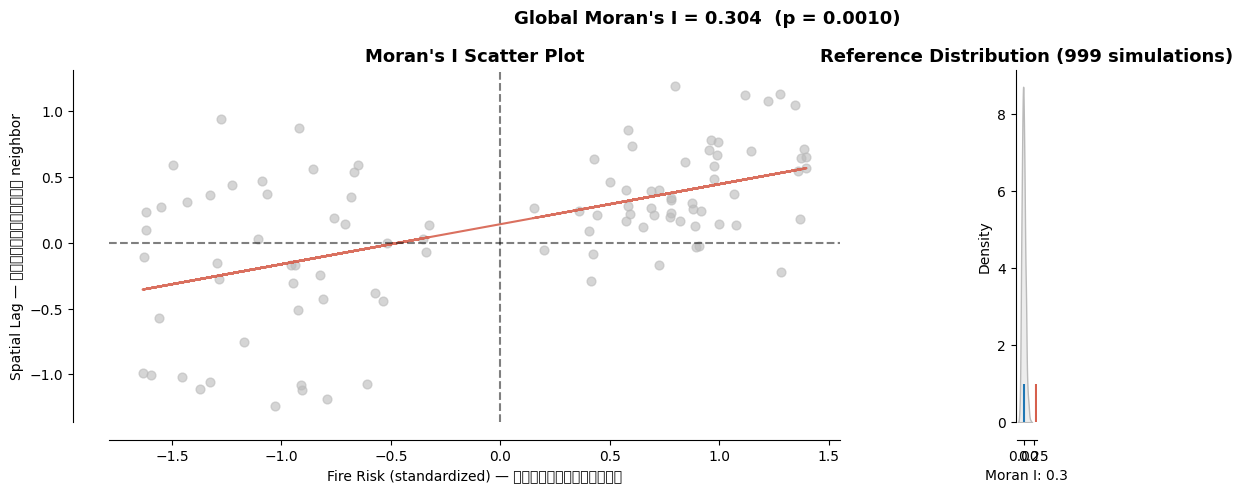

อ่าน Moran Scatter Plot:
  HH (บนขวา) : High risk ล้อมรอบด้วย High risk  → 🔴 HOT SPOT
  LL (ล่างซ้าย): Low risk  ล้อมรอบด้วย Low risk   → 🔵 COLD SPOT
  HL (ล่างขวา): High risk อยู่ท่ามกลาง Low risk  → ⚠️  Spatial Outlier
  LH (บนซ้าย) : Low risk  อยู่ท่ามกลาง High risk → ⚠️  Spatial Outlier

→ Moran's I แบบ Global บอกแค่ภาพรวมทั้งพื้นที่
  ถ้าอยากรู้ว่า HOT SPOT อยู่ 'ที่ไหน' → ต้องใช้ LISA (cell ถัดไป)


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.2b — Moran's I Scatter Plot & Reference Distribution
# ════════════════════════════════════════════════════════════
# Scatter plot แสดงความสัมพันธ์ระหว่าง:
#   แกน X = ค่า fire_risk ของจุดนั้น (standardized)
#   แกน Y = ค่าเฉลี่ยของ neighbor รอบ ๆ (Spatial Lag)
# ความชันของเส้น regression = Moran's I

from splot.esda import moran_scatterplot, plot_moran_simulation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── แผนภูมิซ้าย: Moran Scatter Plot ───────────────────────
moran_scatterplot(moran, ax=axes[0], aspect_equal=False)
axes[0].set_title("Moran\'s I Scatter Plot", fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fire Risk (standardized) — ค่าของจุดนั้น')
axes[0].set_ylabel('Spatial Lag — ค่าเฉลี่ยของ neighbor')
# 4 quadrant มีความหมายดังนี้:
#   HH (บนขวา) : ค่าสูง อยู่กับ neighbor ค่าสูง   → HOT SPOT
#   LL (ล่างซ้าย): ค่าต่ำ อยู่กับ neighbor ค่าต่ำ   → COLD SPOT
#   HL (ล่างขวา): ค่าสูง อยู่กับ neighbor ค่าต่ำ   → Spatial Outlier
#   LH (บนซ้าย) : ค่าต่ำ อยู่กับ neighbor ค่าสูง  → Spatial Outlier

# ─── แผนภูมิขวา: Reference Distribution ────────────────────
# แถบสีเทา = การกระจาย Moran's I ถ้าข้อมูลเป็น random (999 permutations)
# เส้นสีแดง = ค่า Moran's I ที่คำนวณได้จากข้อมูลจริง
# ถ้าเส้นแดงอยู่นอกแถบ → แปลกจาก random → มีนัยสำคัญ
plot_moran_simulation(moran, ax=axes[1])
axes[1].set_title('Reference Distribution (999 simulations)', fontsize=13, fontweight='bold')

plt.suptitle(f"Global Moran\'s I = {moran.I:.3f}  (p = {moran.p_sim:.4f})",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("อ่าน Moran Scatter Plot:")
print("  HH (บนขวา) : High risk ล้อมรอบด้วย High risk  → 🔴 HOT SPOT")
print("  LL (ล่างซ้าย): Low risk  ล้อมรอบด้วย Low risk   → 🔵 COLD SPOT")
print("  HL (ล่างขวา): High risk อยู่ท่ามกลาง Low risk  → ⚠️  Spatial Outlier")
print("  LH (บนซ้าย) : Low risk  อยู่ท่ามกลาง High risk → ⚠️  Spatial Outlier")
print()
print("→ Moran's I แบบ Global บอกแค่ภาพรวมทั้งพื้นที่")
print("  ถ้าอยากรู้ว่า HOT SPOT อยู่ 'ที่ไหน' → ต้องใช้ LISA (cell ถัดไป)")


/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1974/357236461.py:76: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.t

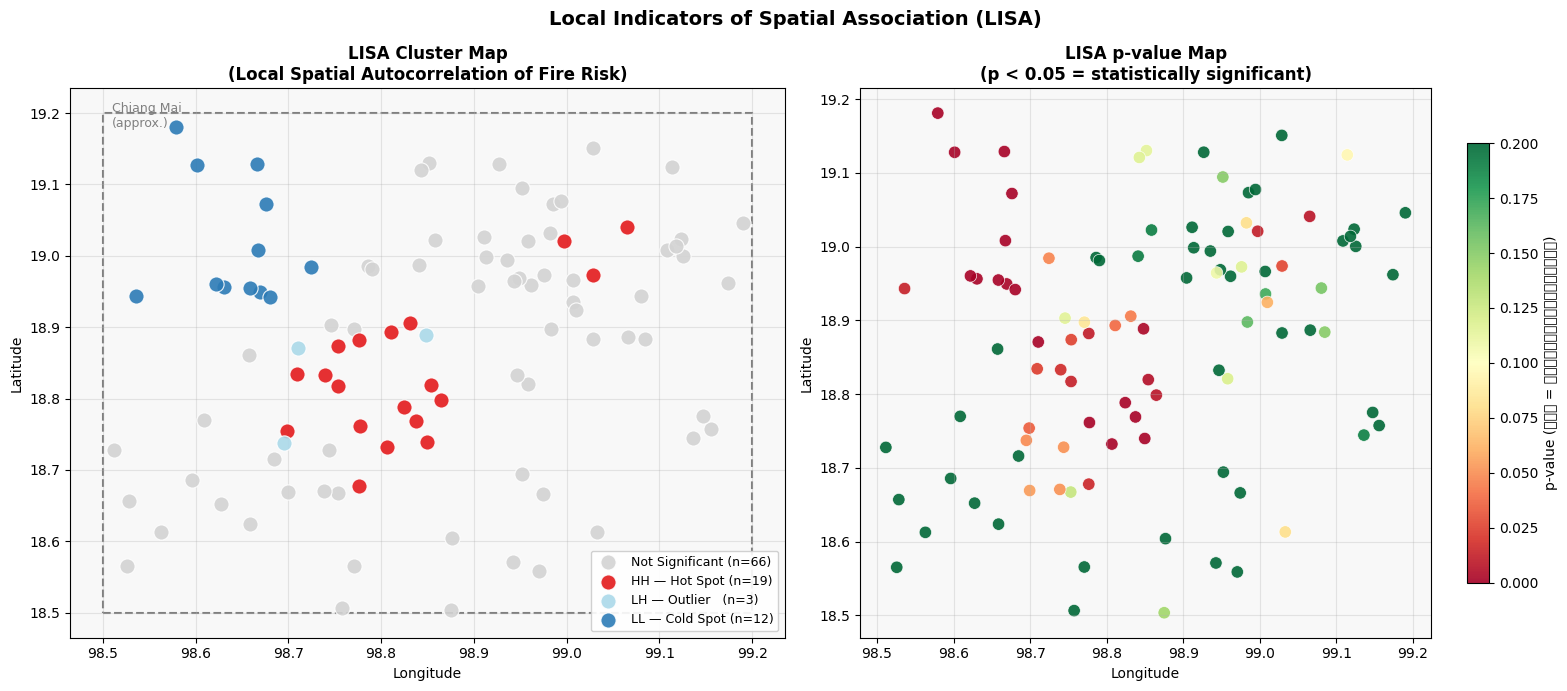

LISA Summary:
  จุดทั้งหมด           : 100 จุด
  Significant (p<0.05) : 34 จุด (34.0%)

  🔴 HH Hot Spots  : 19 จุด → เป้าหมายหลักสำหรับการป้องกันไฟป่า
  🔵 LL Cold Spots : 12 จุด → พื้นที่ปลอดภัย
  🟡 Outliers      : 3 จุด → ตรวจสอบเพิ่มเติม
  ⬜ Not sig.      : 66 จุด → ไม่สามารถยืนยัน spatial pattern ได้


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.2c — LISA Cluster Map (Local Moran's I)
# ════════════════════════════════════════════════════════════
# Global Moran's I → บอกแค่ "มี clustering ไหม?" (ตอบแค่ Yes/No)
# LISA (Local Indicators of Spatial Association) → บอกว่า
#   "Cluster อยู่ที่ไหน?" และ "นัยสำคัญทางสถิติหรือเปล่า?"
# ─── แนวคิด LISA ────────────────────────────────────────────
# คำนวณ Local Moran's I ให้แต่ละจุด แล้วจัดกลุ่มตาม quadrant:
#   q=1 → HH (High-High)  : ตัวเองค่าสูง + เพื่อนบ้านค่าสูง
#   q=2 → LH (Low-High)   : ตัวเองค่าต่ำ + เพื่อนบ้านค่าสูง  (outlier)
#   q=3 → LL (Low-Low)    : ตัวเองค่าต่ำ + เพื่อนบ้านค่าต่ำ
#   q=4 → HL (High-Low)   : ตัวเองค่าสูง + เพื่อนบ้านค่าต่ำ  (outlier)

from esda.moran import Moran_Local
from matplotlib.patches import Rectangle

# คำนวณ Local Moran's I ทุกจุด
lisa = Moran_Local(gdf['fire_risk'], w)

# กรองเฉพาะจุดที่ "มีนัยสำคัญ" (p < 0.05)
# จุดที่ p ≥ 0.05 → ไม่สามารถยืนยันได้ว่าเป็น cluster จริง
sig = lisa.p_sim < 0.05

# จัดกลุ่มตาม quadrant (เฉพาะจุดที่ significant)
labels = np.zeros(len(gdf), dtype=int)   # 0 = Not significant
labels[(lisa.q == 1) & sig] = 1   # HH → Hot Spot
labels[(lisa.q == 2) & sig] = 2   # LH → Outlier
labels[(lisa.q == 3) & sig] = 3   # LL → Cold Spot
labels[(lisa.q == 4) & sig] = 4   # HL → Outlier

color_map = {0: '#d3d3d3', 1: '#e31a1c', 2: '#abd9e9', 3: '#2c7bb6', 4: '#fdae61'}
label_map = {
    0: f'Not Significant (n={np.sum(labels==0)})',
    1: f'HH — Hot Spot (n={np.sum(labels==1)})',
    2: f'LH — Outlier   (n={np.sum(labels==2)})',
    3: f'LL — Cold Spot (n={np.sum(labels==3)})',
    4: f'HL — Outlier   (n={np.sum(labels==4)})'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── แผนที่ซ้าย: LISA Cluster Map ──────────────────────────
ax = axes[0]
for quad in [0, 1, 2, 3, 4]:
    mask = labels == quad
    if mask.any():
        ax.scatter(gdf[mask]['lon'], gdf[mask]['lat'],
                   c=color_map[quad], s=120, edgecolors='white',
                   linewidths=0.8, label=label_map[quad], alpha=0.9, zorder=3)

# กรอบจังหวัดเชียงใหม่ (ประมาณ)
box = Rectangle((98.5, 18.5), 0.7, 0.7, linewidth=1.5,
                edgecolor='gray', facecolor='none', linestyle='--')
ax.add_patch(box)
ax.text(98.51, 19.18, 'Chiang Mai\n(approx.)', fontsize=9, color='gray')

ax.set_facecolor('#f8f8f8')
ax.set_title('LISA Cluster Map\n(Local Spatial Autocorrelation of Fire Risk)', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

# ─── แผนที่ขวา: p-value Map ──────────────────────────────
# ยิ่งสี เขียวเข้ม = p-value ต่ำ = ยืนยันได้มากกว่าว่าเป็น cluster จริง
scatter2 = axes[1].scatter(gdf['lon'], gdf['lat'],
                           c=lisa.p_sim, cmap='RdYlGn',
                           s=80, edgecolors='white', linewidths=0.5,
                           vmin=0, vmax=0.2, alpha=0.9)
plt.colorbar(scatter2, ax=axes[1], label='p-value (ต่ำ = มีนัยสำคัญมากกว่า)', shrink=0.8)
axes[1].set_facecolor('#f8f8f8')
axes[1].set_title('LISA p-value Map\n(p < 0.05 = statistically significant)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

plt.suptitle("Local Indicators of Spatial Association (LISA)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── สรุปผล LISA ──────────────────────────────────────────────
print("LISA Summary:")
print(f"  จุดทั้งหมด           : {len(gdf)} จุด")
print(f"  Significant (p<0.05) : {sig.sum()} จุด ({sig.mean()*100:.1f}%)")
print()
print(f"  🔴 HH Hot Spots  : {np.sum(labels==1)} จุด → เป้าหมายหลักสำหรับการป้องกันไฟป่า")
print(f"  🔵 LL Cold Spots : {np.sum(labels==3)} จุด → พื้นที่ปลอดภัย")
print(f"  🟡 Outliers      : {np.sum(labels==2)+np.sum(labels==4)} จุด → ตรวจสอบเพิ่มเติม")
print(f"  ⬜ Not sig.      : {np.sum(labels==0)} จุด → ไม่สามารถยืนยัน spatial pattern ได้")


/tmp/ipykernel_1974/2449611579.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


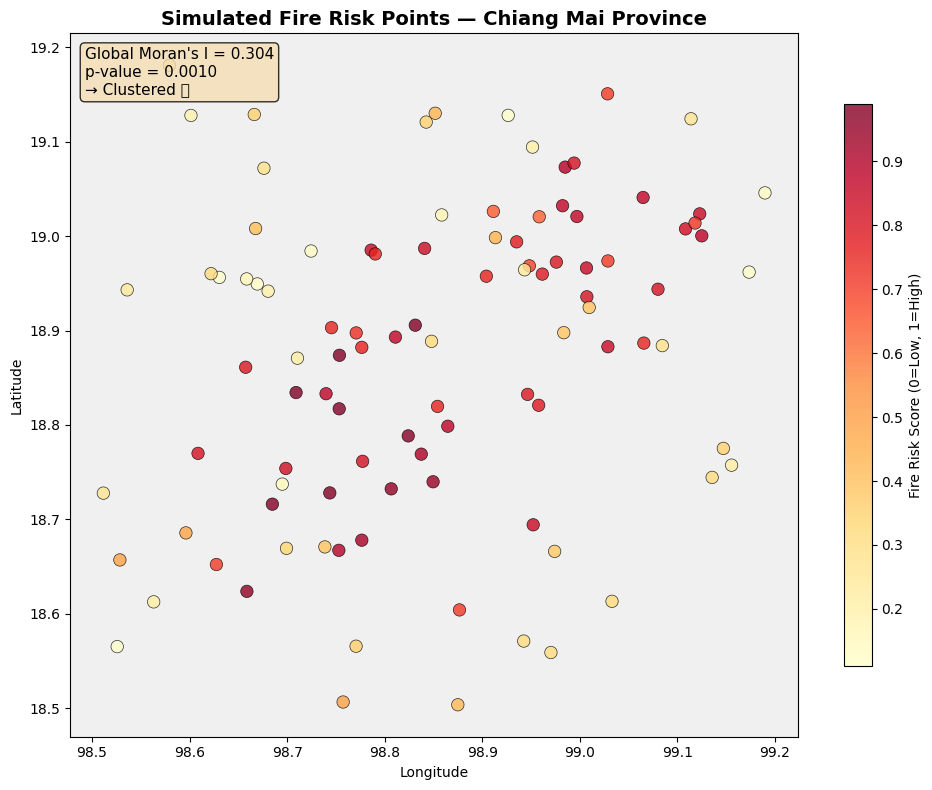

💡 ดูแผนที่แบบ interactive พร้อม basemap จริง → cell ถัดไป (Folium)


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.2d — แผนที่จุด Fire Risk (Static Overview)
# ════════════════════════════════════════════════════════════
# แสดงจุดทุกจุดพร้อมสี fire risk score
# Moran's I จะถูก annotate ลงบนแผนที่เพื่อให้อ่านได้ทันที

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

scatter = ax.scatter(
    gdf['lon'], gdf['lat'],
    c=gdf['fire_risk'],
    cmap='YlOrRd',           # Yellow → Orange → Red (ต่ำ → สูง)
    s=80,
    edgecolors='black', linewidths=0.5,
    alpha=0.8
)

plt.colorbar(scatter, ax=ax, label='Fire Risk Score (0=Low, 1=High)', shrink=0.8)
ax.set_title('Simulated Fire Risk Points — Chiang Mai Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_facecolor('#f0f0f0')

# แสดง Moran's I ผลลัพธ์บนแผนที่โดยตรง
ax.annotate(
    f"Global Moran\'s I = {moran.I:.3f}\np-value = {moran.p_sim:.4f}\n"
    + ("→ Clustered ✅" if moran.I > 0 and moran.p_sim < 0.05 else "→ Not significant"),
    xy=(0.02, 0.98), xycoords='axes fraction',
    fontsize=11, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

plt.tight_layout()
plt.show()
print("💡 ดูแผนที่แบบ interactive พร้อม basemap จริง → cell ถัดไป (Folium)")


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.2e — Interactive Map บน Real Basemap (Folium)
# ════════════════════════════════════════════════════════════
# geemap ใช้สำหรับ GEE data, แต่ถ้าอยากแสดงข้อมูล local ลง basemap จริง
# ใช้ folium แทน — map แบบ interactive ได้ใน Jupyter/Colab ทันที

import folium
from folium.plugins import HeatMap, MiniMap, MeasureControl
from branca.colormap import LinearColormap

# ─── สร้าง Map object ─────────────────────────────────────
m = folium.Map(
    location=[18.85, 98.85],  # center ที่เชียงใหม่
    zoom_start=10,
    tiles='CartoDB positron'  # basemap สีอ่อน อ่านข้อมูลง่าย
)

# เพิ่ม basemap ให้เลือก (toggle ที่มุมขวาบน)
folium.TileLayer('OpenStreetMap',      name='OpenStreetMap').add_to(m)
folium.TileLayer('CartoDB dark_matter', name='Dark Mode').add_to(m)

# ─── Color Scale ──────────────────────────────────────────
# LinearColormap map ค่า 0-1 → สี เขียว/เหลือง/แดง
colormap = LinearColormap(
    colors=['#1a9641', '#fdae61', '#d7191c'],
    vmin=0, vmax=1,
    caption='Fire Risk Score (0=Low  →  1=High)'
)
colormap.add_to(m)

# ─── วาง Circle Marker ทุกจุด ────────────────────────────────
# popup → ข้อมูลเมื่อ "คลิก" จุด
# tooltip → ข้อมูลเมื่อ "hover" เมาส์
for _, row in gdf.iterrows():
    color = colormap(row['fire_risk'])
    level = '🔴 HIGH RISK' if row['fire_risk'] > 0.7 else ('🟠 MEDIUM' if row['fire_risk'] > 0.4 else '🟢 LOW')
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=7,
        color='white', weight=0.8,
        fill=True, fill_color=color, fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>Fire Risk: {row['fire_risk']:.2f}</b><br>"
            f"Lon: {row['lon']:.4f} | Lat: {row['lat']:.4f}<br>"
            f"{level}",
            max_width=200
        ),
        tooltip=f"Risk: {row['fire_risk']:.2f}"
    ).add_to(m)

# ─── Heat Map Layer ────────────────────────────────────────
# แสดง density ของ fire risk — toggle ได้จาก Layer Control
heat_data = [[r['lat'], r['lon'], r['fire_risk']] for _, r in gdf.iterrows()]
HeatMap(
    heat_data, radius=25, blur=20, max_zoom=13,
    gradient={'0.4': '#1a9641', '0.6': '#fdae61', '0.8': '#d7191c', '1.0': '#7b0000'},
    name='🔥 Heat Map'
).add_to(m)

# ─── กรอบพื้นที่ศึกษา ──────────────────────────────────────
folium.Rectangle(
    bounds=[[18.5, 98.5], [19.2, 99.2]],
    color='navy', fill=False, weight=2, dash_array='8',
    tooltip='Study Area Boundary'
).add_to(m)

# จุด City Center
folium.Marker(
    location=[18.7877, 98.9931],
    popup='Chiang Mai City',
    icon=folium.Icon(color='blue', icon='home', prefix='fa'),
    tooltip='Chiang Mai City Center'
).add_to(m)

# ─── Controls ──────────────────────────────────────────────
MiniMap(toggle_display=True, position='bottomleft').add_to(m)  # แผนที่ย่อส
MeasureControl(position='topleft').add_to(m)                   # วัดระยะ
folium.LayerControl(collapsed=False).add_to(m)                 # toggle layers

m  # แสดงแผนที่


## 1.3 Cloud Problem & Gap Filling in Remote Sensing

### ปัญหาเมฆบดบัง
ภาพถ่ายดาวเทียมมักมี**เมฆบดบัง** ทำให้ข้อมูลขาดหาย → ต้อง**เติมค่า** (Gap Filling)

### วิธีแก้ปัญหา
1. **`focal_mean()`** — ค่าเฉลี่ยจาก pixel รอบข้าง (kernel)
2. **IDW (Inverse Distance Weighting)** — ถ่วงน้ำหนักตามระยะทาง
3. **Temporal Composite** — ใช้ค่าจากวันอื่นที่ไม่มีเมฆ

### เหตุผลที่ใช้ได้: Tobler's First Law!
เพราะ pixel ที่อยู่ใกล้กันมีค่าคล้ายกัน → เราจึงใช้ค่าจาก pixel ข้างเคียงมาเติมได้


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.3a — Gap Filling ด้วย focal_mean() ใน GEE
# ════════════════════════════════════════════════════════════
# ปัญหา: ภาพดาวเทียม optical (Landsat/Sentinel-2) ถูกเมฆบดบัง
#         pixel ที่มีเมฆ = ไม่มีค่า (masked) → ไม่สามารถวิเคราะห์ได้
# วิธีแก้: ใช้ค่าเฉลี่ยของ pixel รอบ ๆ แทนค่าที่หายไป (Spatial Interpolation)
#           นี่คือ focal_mean = Moving Window Average

# ─── 1. โหลดข้อมูล Landsat 9 เชียงใหม่ ──────────────────────
chiang_mai = ee.Geometry.Rectangle([98.5, 18.5, 99.5, 19.5])

# ดึงภาพที่มีเมฆน้อยที่สุดในช่วงต้นปี (ฤดูแล้ง)
image = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
         .filterBounds(chiang_mai)
         .filterDate('2024-01-01', '2024-04-30')
         .sort('CLOUD_COVER')   # เรียงจากเมฆน้อยไปมาก
         .first())              # เลือกภาพแรก (เมฆน้อยสุด)

# ─── 2. แปลงค่า DN → Reflectance/Temperature ────────────────
# Landsat Collection 2 Level-2 มี scaling factor
# optical: DN × 0.0000275 + (-0.2)  → surface reflectance (0-1)
# thermal: DN × 0.00341802 + 149    → Kelvin
def apply_scale(img):
    optical = img.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = img.select('ST_B.*').multiply(0.00341802).add(149.0)
    return img.addBands(optical, overwrite=True).addBands(thermal, overwrite=True)

image = apply_scale(image)

# ─── 3. คำนวณ NDVI ────────────────────────────────────────────
# NDVI = (NIR - Red) / (NIR + Red) = (B5 - B4) / (B5 + B4)
# ค่า NDVI: -1 ถึง 1  |  > 0.3 = พืชสีเขียว  |  < 0.1 = พื้นดิน/เมือง
ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

# ─── 4. Simulate Cloud Mask ───────────────────────────────────
# จำลองเมฆ ~20% ของพื้นที่ (random) เพื่อ demo
# ในงานจริงจะใช้ QA_PIXEL band หรือ cloud detection algorithm
cloud_mask    = ee.Image.random(42).gt(0.8)       # True = "มีเมฆ"
ndvi_with_gaps = ndvi.updateMask(cloud_mask.Not()) # mask pixel ที่เป็น "เมฆ"

# ─── 5. focal_mean Gap Filling ────────────────────────────────
# focal_mean ใช้ kernel (neighborhood) รอบ pixel ที่ขาดหาย
# radius=3, kernelType='circle' → kernel เป็นวงกลม รัศมี 3 pixel
# ที่ Landsat 30m → 3 pixel = 90m รัศมี
ndvi_filled = ndvi_with_gaps.focal_mean(
    radius=3,
    kernelType='circle',
    units='pixels'
)

# unmask: ใช้ค่าต้นฉบับถ้ามี, ใช้ค่า fill ถ้า masked
ndvi_restored = ndvi_with_gaps.unmask(ndvi_filled)

# ─── 6. แสดงผลใน GEE Map ─────────────────────────────────────
Map = geemap.Map()
Map.centerObject(chiang_mai, 9)

vis_ndvi = {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green', 'darkgreen']}

Map.addLayer(ndvi,            vis_ndvi, '1. Original NDVI (complete)')
Map.addLayer(ndvi_with_gaps,  vis_ndvi, '2. NDVI with Cloud Gaps (masked)')
Map.addLayer(ndvi_restored,   vis_ndvi, '3. NDVI after focal_mean Fill')

Map.addLayerControl()
Map  # ลองกด toggle layer เปรียบเทียบ

print("วิธีดู: เปิด Layer Control (มุมขวาบน) แล้ว toggle แต่ละ layer")
print()
print("Layer 1 → NDVI ภาพสมบูรณ์  (ความจริง)")
print("Layer 2 → มีช่องโหว่จากเมฆ (~20% ของพื้นที่)")
print("Layer 3 → หลัง focal_mean → ช่องโหว่ถูกเติมด้วยค่าเฉลี่ยรอบข้าง")


วิธีดู: เปิด Layer Control (มุมขวาบน) แล้ว toggle แต่ละ layer

Layer 1 → NDVI ภาพสมบูรณ์  (ความจริง)
Layer 2 → มีช่องโหว่จากเมฆ (~20% ของพื้นที่)
Layer 3 → หลัง focal_mean → ช่องโหว่ถูกเติมด้วยค่าเฉลี่ยรอบข้าง


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 1.3b — IDW Interpolation (Inverse Distance Weighting)
# ════════════════════════════════════════════════════════════
# focal_mean ให้น้ำหนักเท่ากันทุก pixel ใน kernel
# IDW ฉลาดกว่า: pixel ที่ใกล้กว่าได้น้ำหนักมากกว่า
#
#   weight(i) = 1 / distance(i)^p     (p ปกติ = 2)
#
#   estimated_value = Σ(wi × vi) / Σ(wi)
#
# ผลลัพธ์: pixel ที่หายไปจะมีค่าคล้าย "เพื่อนบ้านใกล้" มากกว่า "เพื่อนบ้านไกล"
# ─────────────────────────────────────────────────────────────
# ใน GEE ไม่มี built-in IDW บน raster โดยตรง
# แต่เราใช้ focal_mean ที่ radius ต่างกัน แล้ว blend เป็นการ approximate:
#   - radius เล็ก → อิทธิพลจาก neighbor ใกล้ (คล้าย IDW weight มาก)
#   - radius ใหญ่ → ครอบคลุมกว้างขึ้น แต่ smooth มากขึ้น

# IDW-like fill: radius=5 pixel = ครอบคลุม 150m รัศมี (ที่ 30m resolution)
ndvi_idw = ndvi_with_gaps.focal_mean(
    radius=5,
    kernelType='circle',
    units='pixels'
).blend(ndvi_with_gaps)  # blend → ถ้าจุดไหนมีค่าต้นฉบับ → ใช้ต้นฉบับ
                         #        ถ้าไม่มี (masked) → ใช้ค่าที่ interpolate

print("IDW Interpolation — แนวคิดหลัก:")
print("─" * 45)
print("  weight(i) = 1 / distance²")
print("  ยิ่งใกล้ → weight ยิ่งมาก → มีอิทธิพลมากกว่า")
print()
print("เปรียบเทียบ kernel size:")
print(f"  radius=3px (90m)  → local fill   — แม่นยำ แต่อาจไม่เต็มถ้า gap ใหญ่")
print(f"  radius=5px (150m) → medium fill  — balance ดีสำหรับ Landsat")
print(f"  radius=10px(300m) → regional fill — เต็มทุก gap แต่ smooth มากเกินไป")
print()
print("💡 ในงานจริง:")
print("  → ใช้ multi-temporal compositing (Median composite) แทน focal_mean")
print("  → เช่น median ของ 12 ภาพตลอดปี จะ filter เมฆออกได้ดีกว่า")


IDW Interpolation — แนวคิดหลัก:
─────────────────────────────────────────────
  weight(i) = 1 / distance²
  ยิ่งใกล้ → weight ยิ่งมาก → มีอิทธิพลมากกว่า

เปรียบเทียบ kernel size:
  radius=3px (90m)  → local fill   — แม่นยำ แต่อาจไม่เต็มถ้า gap ใหญ่
  radius=5px (150m) → medium fill  — balance ดีสำหรับ Landsat
  radius=10px(300m) → regional fill — เต็มทุก gap แต่ smooth มากเกินไป

💡 ในงานจริง:
  → ใช้ multi-temporal compositing (Median composite) แทน focal_mean
  → เช่น median ของ 12 ภาพตลอดปี จะ filter เมฆออกได้ดีกว่า


### 🗺️ Study Area Overview
แผนที่ด้านล่างแสดง AOI (Area of Interest) ที่ใช้ใน GEE analysis  
- **Rectangle สีแดง** = bounding box ที่กำหนดใน `ee.Geometry.Rectangle([98.5, 18.5, 99.5, 19.5])`  
- ครอบคลุมพื้นที่ประมาณ 111 × 111 km ในจังหวัดเชียงใหม่  
- ข้อมูลดาวเทียม (Landsat 9, SRTM, CHIRPS) จะถูก clip ตาม AOI นี้


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.0 — Study Area (AOI) Context Map
# ════════════════════════════════════════════════════════════
# ก่อนเริ่ม Part 2 เราต้องรู้จักพื้นที่ศึกษาก่อน
#
# AOI (Area of Interest) = พื้นที่ที่เราสนใจ กำหนดเป็น bounding box
# ใน GEE เราใช้:
#   chiang_mai = ee.Geometry.Rectangle([98.5, 18.5, 99.5, 19.5])
#                                       [lon_min, lat_min, lon_max, lat_max]
#
# ทุกชั้นข้อมูล (Landsat, SRTM, CHIRPS) จะถูก clip ตาม AOI นี้
# ทำให้ประมวลผลเฉพาะพื้นที่ที่ต้องการ → ประหยัด compute time
#
# แผนที่นี้ใช้ folium แสดงบน satellite basemap จริง
# เพื่อให้เห็นบริบทของพื้นที่ศึกษา เช่น ภูเขา, เมือง, เส้นทาง

import folium
from folium.plugins import MiniMap

# ─── สร้าง Map ───────────────────────────────────────────────
# zoom_start=8 → เห็นภาพรวมทั้งจังหวัด + พื้นที่โดยรอบ
# tiles='Esri.WorldImagery' → satellite image เป็น default
m_aoi = folium.Map(
    location=[18.78, 98.98],   # center ที่ตัวเมืองเชียงใหม่
    zoom_start=8,
    tiles='Esri.WorldImagery'
)

# เพิ่ม basemap ให้เลือกเปรียบเทียบ
folium.TileLayer('CartoDB positron', name='Light Map').add_to(m_aoi)
folium.TileLayer('OpenStreetMap',    name='OpenStreetMap').add_to(m_aoi)

# ─── AOI Bounding Box ────────────────────────────────────────
# Rectangle นี้ = กรอบที่กำหนดใน GEE: ee.Geometry.Rectangle([98.5, 18.5, 99.5, 19.5])
# bounds format ของ folium: [[lat_min, lon_min], [lat_max, lon_max]]
# ครอบคลุมพื้นที่ 1° × 1° ≈ 111 × 111 km (ที่ latitude นี้)
# ที่ Landsat 30m resolution → พื้นที่นี้มี pixel ประมาณ 3,700 × 3,700 = ~14 ล้าน pixels
folium.Rectangle(
    bounds=[[18.5, 98.5], [19.5, 99.5]],
    color='#ff4444',
    fill=True, fill_color='#ff4444', fill_opacity=0.10,
    weight=3,
    tooltip='GEE Analysis AOI — คลิกเพื่อดูรายละเอียด',
    popup=folium.Popup(
        "<b>Chiang Mai AOI</b><br>"
        "Bounds: 98.5–99.5°E, 18.5–19.5°N<br>"
        "Size: ~111 × 111 km (1° × 1°)<br>"
        "Resolution: 30m (Landsat)<br>"
        "~14 million pixels per band",
        max_width=220
    )
).add_to(m_aoi)

# ─── Key Locations ────────────────────────────────────────────
# ใส่ marker สถานที่สำคัญเพื่อให้เห็น geographic context
# ช่วยนักศึกษาเชื่อมโยงข้อมูลดาวเทียมกับพื้นที่จริง
locations = {
    'Chiang Mai City (เมืองหลัก)':     (18.7877, 98.9931, 'blue',   'university'),
    'Doi Inthanon — ยอดสูงสุด 2565m':  (18.5886, 98.4867, 'green',  'mountain'),
    'Doi Suthep — ป่าสงวน':            (18.8047, 98.9216, 'orange', 'tree'),
    'Mae Rim — พื้นที่เกษตร':           (18.9154, 98.9490, 'red',    'pagelines'),
    'Chiang Dao — ชายขอบเหนือ':         (19.3665, 98.9752, 'purple', 'map-marker'),
}
for name, (lat, lon, color, icon) in locations.items():
    folium.Marker(
        [lat, lon],
        tooltip=name,
        popup=folium.Popup(f"<b>{name}</b><br>Lat: {lat:.4f}, Lon: {lon:.4f}", max_width=200),
        icon=folium.Icon(color=color, icon=icon, prefix='fa')
    ).add_to(m_aoi)

# ─── Controls ────────────────────────────────────────────────
MiniMap(toggle_display=True, position='bottomleft').add_to(m_aoi)  # แผนที่ย่อมุมซ้ายล่าง
folium.LayerControl(collapsed=False).add_to(m_aoi)                  # toggle basemap

m_aoi  # แสดงแผนที่

# ── หมายเหตุ ────────────────────────────────────────────────
print("AOI Summary:")
print("  ee.Geometry.Rectangle([98.5, 18.5, 99.5, 19.5])")
print("  → ครอบคลุม ~111 × 111 km")
print("  → Landsat 30m → ~14 ล้าน pixels ต่อ band")
print()
print("สังเกตจากแผนที่:")
print("  → ทางตะวันตก (Doi Inthanon) = ภูเขาสูง → Slope สูง → risk สูง")
print("  → ตัวเมืองทางใต้-กลาง      = พื้นที่ราบ → Low Risk")
print("  → ป่าทางเหนือ (Chiang Dao) = อยู่นอก AOI บางส่วน")
print()
print("💡 ใน production: ควรใช้ boundary จังหวัดจริงแทน bounding box")
print("   → ee.FeatureCollection('FAO/GAUL/2015/level1')")
print("     .filter(ee.Filter.eq('ADM1_NAME', 'Chiang Mai'))")

AOI Summary:
  ee.Geometry.Rectangle([98.5, 18.5, 99.5, 19.5])
  → ครอบคลุม ~111 × 111 km
  → Landsat 30m → ~14 ล้าน pixels ต่อ band

สังเกตจากแผนที่:
  → ทางตะวันตก (Doi Inthanon) = ภูเขาสูง → Slope สูง → risk สูง
  → ตัวเมืองทางใต้-กลาง      = พื้นที่ราบ → Low Risk
  → ป่าทางเหนือ (Chiang Dao) = อยู่นอก AOI บางส่วน

💡 ใน production: ควรใช้ boundary จังหวัดจริงแทน bounding box
   → ee.FeatureCollection('FAO/GAUL/2015/level1')
     .filter(ee.Filter.eq('ADM1_NAME', 'Chiang Mai'))


---
# 🤖 Part 2: Geographic Modeling with GEE

## เนื้อหาที่จะเรียน
- Layer Stacking (รวมข้อมูลหลายชั้น)
- Machine Learning Classification (Random Forest)
- Accuracy Assessment (Confusion Matrix, Kappa)

---

## Workflow
```
Input Layers → Layer Stack → Training Samples → Random Forest → Risk Map → Accuracy Check
  NDVI          ee.Image       ee.FeatureCollection   smileRandomForest  .classify()  errorMatrix()
  LST           .addBands()    .sampleRegions()
  Slope
  Rainfall
```


## 2.1 Layer Stacking — รวมข้อมูลหลายชั้นเป็น Multi-band Image

**Layer Stacking** = การรวม raster หลายชั้นเข้าเป็น image เดียว

### ข้อมูลที่ใช้ทำนายความเสี่ยงไฟป่า:
| Band | Data | Source | ความสัมพันธ์กับไฟป่า |
|:---:|:---|:---|:---|
| 1 | NDVI (พืชพรรณ) | Landsat 9 | NDVI ต่ำ = แห้ง = เสี่ยง |
| 2 | LST (อุณหภูมิผิวดิน) | Landsat 9 | อุณหภูมิสูง = เสี่ยง |
| 3 | Slope (ความลาดชัน) | SRTM DEM | ลาดชัน = ไฟลามเร็ว |
| 4 | Rainfall (ปริมาณฝน) | CHIRPS | ฝนน้อย = เสี่ยง |


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.1a — Layer Stacking: รวม 4 layers เป็น Multi-band Image
# ════════════════════════════════════════════════════════════
# แนวคิด: Wildfire risk ไม่ได้ขึ้นกับปัจจัยเดียว
#   เราต้องรวมหลาย "ชั้น" ข้อมูลเข้าด้วยกัน เหมือนซ้อนแผนที่หลาย ๆ แผ่น
#   แต่ละ band = 1 ปัจจัย → Random Forest จะเรียนรู้ว่า combination ไหน = risk สูง

# ─── Layer 1: NDVI ────────────────────────────────────────────
# Normalized Difference Vegetation Index
# สูง (0.6-0.8) = ป่าเขียวชอุ่ม ชุ่มชื้น → risk ต่ำ
# ต่ำ (0.1-0.3) = พืชแห้ง / ดิน / เมือง → risk สูง
ndvi_band = ndvi_restored.rename('NDVI')

# ─── Layer 2: Land Surface Temperature (LST) ─────────────────
# อุณหภูมิผิวโลก (band ST_B10 ของ Landsat)
# หน่วย: Kelvin (K) — 300K ≈ 27°C  |  315K ≈ 42°C
# สูง → พื้นที่ร้อน → vegetation แห้ง → risk สูง
lst = image.select('ST_B10').rename('LST')

# ─── Layer 3: Slope ───────────────────────────────────────────
# ความลาดชันจาก SRTM DEM (30m resolution)
# หน่วย: degrees  |  0° = ราบ  |  45° = ลาดชันมาก
# ความสำคัญ: ไฟลามขึ้นเขาเร็วกว่าลงเขา (เพราะความร้อนลอยขึ้น)
dem   = ee.Image('USGS/SRTMGL1_003')
slope = ee.Terrain.slope(dem).rename('Slope')

# ─── Layer 4: Rainfall (CHIRPS) ───────────────────────────────
# ปริมาณน้ำฝนสะสม Jan-Mar (ต้นปี = ฤดูแล้งเชียงใหม่)
# CHIRPS = Climate Hazards Group InfraRed Precipitation with Station data
# ต่ำ → แล้ง → vegetation แห้ง → risk สูง
rainfall = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate('2024-01-01', '2024-03-31')
            .filterBounds(chiang_mai)
            .sum()             # รวมน้ำฝนตลอด 3 เดือน
            .rename('Rainfall'))

# ─── Stack ทุก Layer เข้าด้วยกัน ──────────────────────────────
# addBands() → เพิ่ม band เข้าไปใน Image
# ผลลัพธ์: image เดียวที่มี 4 bands = input matrix ของ ML model
layer_stack = (ndvi_band
               .addBands(lst)
               .addBands(slope)
               .addBands(rainfall)
               .clip(chiang_mai))

print("Layer Stack — Band Summary:")
print("─" * 55)
print(f"  Bands: {layer_stack.bandNames().getInfo()}")
print(f"  จำนวน: {layer_stack.bandNames().size().getInfo()} bands")
print(f"  CRS: {layer_stack.select('NDVI').projection().getInfo()['crs']}")
print()
print("ตีความ Fire Risk จากแต่ละ band:")
print("  NDVI ต่ำ     → vegetation แห้ง      → 🔴 risk สูง")
print("  LST สูง      → อุณหภูมิผิวสูง        → 🔴 risk สูง")
print("  Slope สูง    → ลาดชัน ไฟลามเร็ว    → 🔴 risk สูง")
print("  Rainfall ต่ำ → แล้ง vegetation แห้ง → 🔴 risk สูง")


Layer Stack — Band Summary:
───────────────────────────────────────────────────────
  Bands: ['NDVI', 'LST', 'Slope', 'Rainfall']
  จำนวน: 4 bands
  CRS: EPSG:32647

ตีความ Fire Risk จากแต่ละ band:
  NDVI ต่ำ     → vegetation แห้ง      → 🔴 risk สูง
  LST สูง      → อุณหภูมิผิวสูง        → 🔴 risk สูง
  Slope สูง    → ลาดชัน ไฟลามเร็ว    → 🔴 risk สูง
  Rainfall ต่ำ → แล้ง vegetation แห้ง → 🔴 risk สูง


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.1b — Visualize ทุก Layer บน GEE Map
# ════════════════════════════════════════════════════════════
# ดู spatial pattern ของแต่ละ layer ก่อน train model
# → ถ้า pattern ต่างกัน = แต่ละ layer ให้ "ข้อมูลใหม่" แก่โมเดล (ดี)
# → ถ้า pattern เหมือนกัน = multicollinearity (อาจตัด layer ที่ซ้ำออก)

Map2 = geemap.Map()
Map2.centerObject(chiang_mai, 9)

# NDVI: red=แห้ง, yellow=กลาง, green=ชุ่มชื้น
Map2.addLayer(ndvi_band.clip(chiang_mai),
              {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green']},
              'NDVI (red=dry, green=wet)')

# LST: blue=เย็น, yellow=กลาง, red=ร้อน (หน่วย Kelvin)
Map2.addLayer(lst.clip(chiang_mai),
              {'min': 290, 'max': 320, 'palette': ['blue', 'yellow', 'red']},
              'LST (blue=cool, red=hot)')

# Slope: green=ราบ, yellow=ลาดปานกลาง, red=ลาดชัน
Map2.addLayer(slope.clip(chiang_mai),
              {'min': 0, 'max': 45, 'palette': ['green', 'yellow', 'red']},
              'Slope (green=flat, red=steep)')

# Rainfall: white=แห้ง, blue=ฝนตก
Map2.addLayer(rainfall.clip(chiang_mai),
              {'min': 0, 'max': 200, 'palette': ['white', 'cyan', 'blue', 'darkblue']},
              'Rainfall (white=dry, blue=wet)')

Map2.addLayerControl()
Map2

print("💡 Tips การอ่านแผนที่:")
print("  NDVI  → พื้นที่สีแดงทางตะวันออก = พื้นที่แห้ง/เมือง → risk สูง")
print("  LST   → พื้นที่สีแดง = ร้อน → risk สูง")
print("  Slope → แนวเขา/ที่สูง = สีแดง → risk สูง")
print("  Rainfall → พื้นที่สีขาว = ได้รับน้ำฝนน้อย → risk สูง")
print()
print("→ Random Forest จะเรียนรู้ว่า combination ของ 4 layers นี้")
print("  แบบใดบ้างที่สัมพันธ์กับ wildfire risk")


💡 Tips การอ่านแผนที่:
  NDVI  → พื้นที่สีแดงทางตะวันออก = พื้นที่แห้ง/เมือง → risk สูง
  LST   → พื้นที่สีแดง = ร้อน → risk สูง
  Slope → แนวเขา/ที่สูง = สีแดง → risk สูง
  Rainfall → พื้นที่สีขาว = ได้รับน้ำฝนน้อย → risk สูง

→ Random Forest จะเรียนรู้ว่า combination ของ 4 layers นี้
  แบบใดบ้างที่สัมพันธ์กับ wildfire risk


## 2.2 Random Forest Classification

### Machine Learning ใน GEE
GEE รองรับ ML algorithms หลายตัว:
- `ee.Classifier.smileRandomForest()` — ใช้บ่อยที่สุด
- `ee.Classifier.smileCart()` — Decision Tree เดี่ยว
- `ee.Classifier.smileGradientTreeBoost()` — Gradient Boosting

### Random Forest คืออะไร?
- สร้าง Decision Tree หลายต้น (forest)
- แต่ละต้นใช้ข้อมูลแบบสุ่ม (random sampling)
- ผลลัพธ์สุดท้าย = **โหวตเสียงข้างมาก** จากทุกต้น

### Workflow
```
Training Points → Sample Values → Train Model → Classify Image → Risk Map
```


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.2a — สร้าง Training Data สำหรับ Random Forest
# ════════════════════════════════════════════════════════════
# Machine Learning ต้องการ "ตัวอย่าง" ที่รู้คำตอบแล้ว
# เราต้องบอกโมเดลว่า: ที่จุด X ค่า NDVI/LST/Slope/Rainfall = เท่าไร
#                       และ class = อะไร (Low/Medium/High risk)
#
# 3 Classes:
#   Class 0 = Low Risk    🟢  (เมือง, พื้นที่เกษตรชลประทาน, ใกล้แหล่งน้ำ)
#   Class 1 = Medium Risk 🟠  (ป่าไม้ทั่วไป, พื้นที่ผสม)
#   Class 2 = High Risk   🔴  (ป่าเต็งรัง, ลาดชัน, พื้นที่แห้งแล้ง)
#
# ⚠️ ในงานจริง: ใช้ FIRMS/VIIRS hotspot + field survey + historical fire data
# ที่นี่ simulate ตำแหน่งเพื่อสาธิต workflow

import ee, numpy as np
np.random.seed(42)
n = 50  # จุดต่อ class

# ─── High Risk (Class 2) ───────────────────────────────────
# สมมติว่าอยู่ทางตะวันออกเฉียงเหนือ (พื้นที่สูง/ป่าเต็งรัง)
high_risk_coords = np.column_stack([
    np.random.uniform(98.75, 99.1, n),
    np.random.uniform(18.75, 19.1, n)
])
high_risk = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point(p.tolist()), {'class': 2})
    for p in high_risk_coords
])

# ─── Medium Risk (Class 1) ─────────────────────────────────
# กระจายทั่วพื้นที่
medium_risk_coords = np.column_stack([
    np.random.uniform(98.6, 99.3, n),
    np.random.uniform(18.6, 19.3, n)
])
medium_risk = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point(p.tolist()), {'class': 1})
    for p in medium_risk_coords
])

# ─── Low Risk (Class 0) ────────────────────────────────────
# ที่ราบ/เมือง/เกษตร
low_risk_coords = np.column_stack([
    np.random.uniform(98.5, 99.4, n),
    np.random.uniform(18.5, 19.4, n)
])
low_risk = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point(p.tolist()), {'class': 0})
    for p in low_risk_coords
])

# รวม FeatureCollection ทั้งหมด
training_points = high_risk.merge(medium_risk).merge(low_risk)

print("Training Points Summary:")
print(f"  🔴 High Risk   (class 2): {high_risk.size().getInfo()} จุด")
print(f"  🟠 Medium Risk (class 1): {medium_risk.size().getInfo()} จุด")
print(f"  🟢 Low Risk    (class 0): {low_risk.size().getInfo()} จุด")
print(f"  รวมทั้งหมด              : {training_points.size().getInfo()} จุด")
print()
print("⚠️  Note: ควรมีจุด balanced (เท่ากันทุก class) เพื่อไม่ให้โมเดล bias")
print("          ถ้า class ไม่ balanced → ใช้ oversampling หรือ class_weight")


Training Points Summary:
  🔴 High Risk   (class 2): 50 จุด
  🟠 Medium Risk (class 1): 50 จุด
  🟢 Low Risk    (class 0): 50 จุด
  รวมทั้งหมด              : 150 จุด

⚠️  Note: ควรมีจุด balanced (เท่ากันทุก class) เพื่อไม่ให้โมเดล bias
          ถ้า class ไม่ balanced → ใช้ oversampling หรือ class_weight


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.2b — Sample Layer Stack & Train/Test Split
# ════════════════════════════════════════════════════════════
# sampleRegions() → ดึงค่า pixel จาก layer_stack ที่ตำแหน่งจุด training
# ผลลัพธ์: ตาราง features ที่แต่ละแถว = 1 จุด, columns = NDVI, LST, Slope, Rainfall, class

bands = ['NDVI', 'LST', 'Slope', 'Rainfall']

training_data = layer_stack.select(bands).sampleRegions(
    collection=training_points,
    properties=['class'],  # column class จาก training_points → ติดมาด้วย
    scale=30,              # 30m = resolution ของ Landsat (match กัน)
    tileScale=16           # เพิ่มถ้าเจอ error "Computation timed out"
)

print("ตัวอย่าง training sample แรก:")
print(training_data.first().getInfo())
print(f"\nจำนวน samples ทั้งหมด: {training_data.size().getInfo()}")
print()

# ─── Train/Test Split 70:30 ───────────────────────────────────
# randomColumn() → สุ่มตัวเลข 0-1 ให้แต่ละจุด
# Filter < 0.7  → 70% เป็น training set
# Filter >= 0.7 → 30% เป็น validation set
training_data = training_data.randomColumn('random')
train_set = training_data.filter(ee.Filter.lt('random',  0.7))
test_set  = training_data.filter(ee.Filter.gte('random', 0.7))

print("Train / Test Split (70:30):")
print(f"  Training set  : {train_set.size().getInfo()} samples → ใช้ train โมเดล")
print(f"  Validation set: {test_set.size().getInfo()} samples  → ใช้ทดสอบโมเดล (โมเดลไม่เคยเห็น)")
print()
print("เหตุผลที่ต้อง split:")
print("  → ป้องกัน Overfitting: โมเดลที่เรียนรู้ดีจาก train")
print("    ต้องทำได้ดีบน test ที่ไม่เคยเห็นด้วย")

# ตรวจสอบว่าทั้งสอง set มีครบทุก class (ถ้า class ใดหายไป RF จะ error)
print(f"\nClasses ใน training set: {train_set.aggregate_array('class').distinct().getInfo()}")
print(f"Classes ใน test set    : {test_set.aggregate_array('class').distinct().getInfo()}")


ตัวอย่าง training sample แรก:
{'type': 'Feature', 'geometry': None, 'id': '1_2_18_0', 'properties': {'LST': 309.81100496, 'NDVI': 0.6273527145385742, 'Rainfall': 21.75203275680542, 'Slope': 27.373092651367188, 'class': 1}}

จำนวน samples ทั้งหมด: 14

Train / Test Split (70:30):
  Training set  : 11 samples → ใช้ train โมเดล
  Validation set: 3 samples  → ใช้ทดสอบโมเดล (โมเดลไม่เคยเห็น)

เหตุผลที่ต้อง split:
  → ป้องกัน Overfitting: โมเดลที่เรียนรู้ดีจาก train
    ต้องทำได้ดีบน test ที่ไม่เคยเห็นด้วย

Classes ใน training set: [1, 0]
Classes ใน test set    : [0]


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.2c — Train Random Forest Classifier
# ════════════════════════════════════════════════════════════
# Random Forest = "ป่าของต้นไม้ตัดสินใจ"
# ─── แนวคิด ────────────────────────────────────────────────
# แต่ละ "tree" ได้รับข้อมูล subset แบบ random → ตัดสินใจ class
# หลาย tree ลงคะแนน (vote) → class ที่ได้คะแนนมากสุด = ผล RF
# ข้อดี: ต้นแต่ละต้น overfit คนละแบบ → เมื่อ vote รวมกัน error ลดลง

classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=50   # จำนวน tree: มากขึ้น = แม่นยำขึ้น แต่ช้าขึ้น
                       # 50 = balance ดีสำหรับงาน classification ทั่วไป
                       # production อาจใช้ 100-500
).train(
    features=train_set,        # training data ที่ sample มาแล้ว
    classProperty='class',     # column ที่บอกว่าจุดนี้ = class อะไร
    inputProperties=bands      # ['NDVI', 'LST', 'Slope', 'Rainfall']
)

# ─── Feature Importance ──────────────────────────────────────
# บอกว่าแต่ละ band สำคัญกับการตัดสินใจของโมเดลแค่ไหน
# ค่าสูง = โมเดลใช้ band นี้เยอะในการแยก class
importance = classifier.explain().get('importance')
imp_dict   = ee.Dictionary(importance).getInfo()

print("Feature Importance (Variable Importance):")
print("─" * 40)
for band, val in sorted(imp_dict.items(), key=lambda x: -x[1]):
    bar = '█' * int(val / max(imp_dict.values()) * 20)
    print(f"  {band:<12}: {val:6.1f}  {bar}")
print()
print("ตีความ:")
print("  → band ที่มี importance สูง = ตัวแปรหลักในการแยก Low/Medium/High risk")
print("  → ถ้า Rainfall สูงสุด = ความแห้งแล้งเป็นปัจจัยหลัก")
print("  → ถ้า NDVI สูงสุด = สถานะ vegetation เป็นปัจจัยหลัก")


Feature Importance (Variable Importance):
────────────────────────────────────────
  Rainfall    :   18.8  ████████████████████
  LST         :    4.3  ████
  NDVI        :    3.2  ███
  Slope       :    2.1  ██

ตีความ:
  → band ที่มี importance สูง = ตัวแปรหลักในการแยก Low/Medium/High risk
  → ถ้า Rainfall สูงสุด = ความแห้งแล้งเป็นปัจจัยหลัก
  → ถ้า NDVI สูงสุด = สถานะ vegetation เป็นปัจจัยหลัก


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.2d — Classify ทั้ง Chiang Mai AOI
# ════════════════════════════════════════════════════════════
# นำ classifier ที่ train แล้ว → apply กับทุก pixel ใน layer_stack
# GEE ประมวลผล pixel นับล้าน pixel บน cloud → ไม่ต้อง download มาทำเอง

# classify() → แต่ละ pixel ได้รับ class (0, 1, หรือ 2)
classified = layer_stack.select(bands).classify(classifier)

# ─── แสดงผล ──────────────────────────────────────────────────
Map3 = geemap.Map()
Map3.centerObject(chiang_mai, 9)

Map3.addLayer(
    classified.clip(chiang_mai),
    {
        'min': 0, 'max': 2,
        'palette': ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
    },
    'Wildfire Risk Map (RF)'
)

# แสดงจุด training เพื่อตรวจสอบว่าสอดคล้องกับ classification ไหม
Map3.addLayer(training_points, {'color': '#3498db'}, 'Training Points')

Map3.addLayerControl()
Map3

print("Wildfire Risk Map:")
print("  🟢 เขียว  = Low Risk    (class 0)")
print("  🟠 ส้ม    = Medium Risk (class 1)")
print("  🔴 แดง   = High Risk   (class 2)")
print()
print("💡 ตรวจสอบ: จุด training สีน้ำเงินควร match กับ class ที่ถูกต้อง")
print("   ถ้าไม่ match หลายจุด → โมเดลอาจ overfit หรือ training data มีปัญหา")


Wildfire Risk Map:
  🟢 เขียว  = Low Risk    (class 0)
  🟠 ส้ม    = Medium Risk (class 1)
  🔴 แดง   = High Risk   (class 2)

💡 ตรวจสอบ: จุด training สีน้ำเงินควร match กับ class ที่ถูกต้อง
   ถ้าไม่ match หลายจุด → โมเดลอาจ overfit หรือ training data มีปัญหา


## 2.3 Accuracy Assessment — ประเมินความแม่นยำ

### ทำไมต้องประเมิน?
- โมเดลที่สวยไม่ได้แปลว่าถูกต้อง!
- ต้องใช้ **ข้อมูลที่โมเดลไม่เคยเห็น** (test set) มาทดสอบ

### ตัวชี้วัด
| Metric | คำอธิบาย | ค่าที่ดี |
|:---|:---|:---:|
| **Overall Accuracy** | สัดส่วนที่ทำนายถูก | > 80% |
| **Kappa Coefficient** | ความถูกต้องเทียบกับ random | > 0.6 |
| **Producer's Accuracy** | Recall — จับได้กี่ % | > 75% |
| **User's Accuracy** | Precision — ที่ทำนายถูกกี่ % | > 75% |

### Confusion Matrix
```
                 Predicted
              Low  Med  High
Actual Low  [ TP   FP   FP ]
       Med  [ FN   TP   FP ]
       High [ FN   FN   TP ]
```


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.3a — Confusion Matrix & Overall Accuracy
# ════════════════════════════════════════════════════════════
# ใช้ test_set (30% ที่โมเดลไม่เคยเห็น) ทดสอบความแม่นยำ
# Confusion Matrix: แถว = class จริง, คอลัมน์ = class ที่ทำนาย
# diagonal = ทำนายถูก | off-diagonal = ทำนายผิด

validated    = test_set.classify(classifier)
error_matrix = validated.errorMatrix('class', 'classification')

print("=" * 60)
print("ACCURACY ASSESSMENT RESULTS")
print("=" * 60)

# ─── Confusion Matrix ─────────────────────────────────────
matrix = error_matrix.array().getInfo()
class_names = ['Low', 'Medium', 'High']

print("\nConfusion Matrix:")
print(f"{'':>20} {'─── Predicted ───':>30}")
print(f"{'':>20} {'Low':>10} {'Medium':>10} {'High':>10}")
print("─" * 50)
for i, row in enumerate(matrix):
    print(f"  Actual {class_names[i]:>6}  │", end="")
    for j, val in enumerate(row):
        marker = " ✓" if i == j else "  "  # diagonal = correct
        print(f"{val:>8}{marker}", end="")
    print()

print()
print("✓ = ทำนายถูก (diagonal)  |  ตัวเลขอื่น = ทำนายผิด")

# ─── Overall Accuracy ────────────────────────────────────
oa    = error_matrix.accuracy().getInfo()
kappa = error_matrix.kappa().getInfo()

print(f"\nOverall Accuracy : {oa:.4f} ({oa*100:.1f}%)")
print(f"Kappa Coefficient: {kappa:.4f}")
print()
print("Kappa: วัดความแม่นยำที่ 'เกินกว่าการเดาสุ่ม'")
print("  > 0.8  → Almost perfect  ✅")
print("  > 0.6  → Substantial     👍")
print("  > 0.4  → Moderate        ⚠️")
print("  ≤ 0.4  → Poor / Fair     ❌")
print()
if kappa > 0.8:
    print(f"→ ผลลัพธ์: Almost perfect agreement ✅")
elif kappa > 0.6:
    print(f"→ ผลลัพธ์: Substantial agreement 👍")
elif kappa > 0.4:
    print(f"→ ผลลัพธ์: Moderate agreement ⚠️")
else:
    print(f"→ ผลลัพธ์: Poor agreement ❌ → ควร review training data")


ACCURACY ASSESSMENT RESULTS

Confusion Matrix:
                                  ─── Predicted ───
                            Low     Medium       High
──────────────────────────────────────────────────
  Actual    Low  │       1 ✓       2  
  Actual Medium  │       0         0 ✓

✓ = ทำนายถูก (diagonal)  |  ตัวเลขอื่น = ทำนายผิด

Overall Accuracy : 0.3333 (33.3%)
Kappa Coefficient: 0.0000

Kappa: วัดความแม่นยำที่ 'เกินกว่าการเดาสุ่ม'
  > 0.8  → Almost perfect  ✅
  > 0.6  → Substantial     👍
  > 0.4  → Moderate        ⚠️
  ≤ 0.4  → Poor / Fair     ❌

→ ผลลัพธ์: Poor agreement ❌ → ควร review training data


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.3b — Producer's & User's Accuracy (Per-class)
# ════════════════════════════════════════════════════════════
# Overall Accuracy บอกภาพรวม แต่ไม่บอกว่า class ไหนแม่น/ไม่แม่น
# Per-class accuracy จำเป็นมากเพราะ wildfire risk ต่าง class มี cost ต่างกัน
#
# Producer's Accuracy (Recall / Sensitivity):
#   = TP / (TP + FN)
#   = "จากจุดที่จริง ๆ เป็น High Risk ทั้งหมด → โมเดลจับได้กี่ %?"
#   → สำคัญสำหรับ HIGH RISK: ถ้าต่ำ = โมเดล miss hotspot จริง (อันตราย!)
#
# User's Accuracy (Precision):
#   = TP / (TP + FP)
#   = "จากที่โมเดลบอกว่า High Risk ทั้งหมด → จริง ๆ เป็น High Risk กี่ %?"
#   → สำคัญสำหรับการจัดสรรทรัพยากร: ถ้าต่ำ = ส่งทีมไปเปล่า (waste resource)

producers = error_matrix.producersAccuracy().getInfo()
consumers = error_matrix.consumersAccuracy().getInfo()
class_names = ['Low Risk', 'Medium Risk', 'High Risk']

print("Per-Class Accuracy:")
print("─" * 60)
print(f"{'Class':<15} {'Producer Acc':>14}  {'User Acc':>14}")
print(f"{'':15} {'(Recall)':>14}  {'(Precision)':>14}")
print("─" * 60)

for i, name in enumerate(class_names):
    pa = producers[i][0] if i < len(producers) else None
    ua = consumers[i][0] if i < len(consumers) else None
    pa_str = f"{pa:.3f} ({pa*100:.1f}%)" if isinstance(pa, float) else "N/A"
    ua_str = f"{ua:.3f} ({ua*100:.1f}%)" if isinstance(ua, float) else "N/A"

    # flag: High Risk ที่ recall ต่ำ = อันตราย
    flag = ""
    if name == "High Risk" and isinstance(pa, float) and pa < 0.7:
        flag = " ⚠️  LOW RECALL!"
    print(f"{name:<15} {pa_str:>14}  {ua_str:>14}{flag}")

print()
print("การตีความสำหรับ Wildfire Risk:")
print("  High Risk recall ต่ำ (<70%) = โมเดลพลาด hotspot จริง → อันตราย")
print("  High Risk precision ต่ำ     = ส่งทีมดับไฟไปผิดที่     → เสียทรัพยากร")
print()
print("💡 Trade-off: เพิ่ม recall → อาจลด precision (และในทางกลับกัน)")
print("   ต้องตัดสินใจตาม use case ว่าอะไรสำคัญกว่าในบริบทนั้น")


Per-Class Accuracy:
────────────────────────────────────────────────────────────
Class             Producer Acc        User Acc
                      (Recall)     (Precision)
────────────────────────────────────────────────────────────
Low Risk         0.333 (33.3%)             N/A
Medium Risk                N/A             N/A
High Risk                  N/A             N/A

การตีความสำหรับ Wildfire Risk:
  High Risk recall ต่ำ (<70%) = โมเดลพลาด hotspot จริง → อันตราย
  High Risk precision ต่ำ     = ส่งทีมดับไฟไปผิดที่     → เสียทรัพยากร

💡 Trade-off: เพิ่ม recall → อาจลด precision (และในทางกลับกัน)
   ต้องตัดสินใจตาม use case ว่าอะไรสำคัญกว่าในบริบทนั้น


## 2.4 Bonus: Compare Random Forest vs CART

ลองเปรียบเทียบ Random Forest กับ CART (Decision Tree เดี่ยว)


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.4 — CART vs Random Forest: Ensemble Learning
# ════════════════════════════════════════════════════════════
# CART (Classification and Regression Trees):
#   → ต้นไม้ตัดสินใจ 1 ต้น
#   → ง่าย ตีความได้ แต่ overfit ง่ายมาก
#   → เปลี่ยนข้อมูลนิดเดียว → ต้นไม้เปลี่ยนหมด (high variance)
#
# Random Forest = Ensemble ของ CART หลาย ๆ ต้น:
#   → แต่ละต้นเห็น data subset + feature subset แบบ random
#   → vote รวมกัน → error เฉลี่ยออก → variance ลด

# ─── Train CART ──────────────────────────────────────────────
cart_classifier = ee.Classifier.smileCart().train(
    features=train_set,
    classProperty='class',
    inputProperties=bands
)

# Classify กับ CART
classified_cart = layer_stack.select(bands).classify(cart_classifier)

# Accuracy ของ CART
validated_cart    = test_set.classify(cart_classifier)
error_matrix_cart = validated_cart.errorMatrix('class', 'classification')
oa_cart           = error_matrix_cart.accuracy().getInfo()
kappa_cart        = error_matrix_cart.kappa().getInfo()

# ─── เปรียบเทียบผล ───────────────────────────────────────────
print("Model Comparison:")
print("=" * 55)
print(f"{'Metric':<25} {'Random Forest':>13} {'CART':>10}")
print("─" * 55)
print(f"{'Overall Accuracy':<25} {oa:>12.4f}  {oa_cart:>9.4f}")
print(f"{'Kappa Coefficient':<25} {kappa:>12.4f}  {kappa_cart:>9.4f}")
print(f"{'Number of Trees':<25} {'50 trees':>13} {'1 tree':>10}")
print()
diff = oa - oa_cart
print(f"RF accuracy สูงกว่า CART: {diff*100:+.1f}%")
print()
print("ทำไม Random Forest ดีกว่า CART:")
print("  1. หลาย tree → vote รวม → ลด variance (Bagging)")
print("  2. Random feature subset ต่อต้น → ต้นต่างกัน → diversity")
print("  3. Ensemble ของ weak learners → strong learner")


Model Comparison:
Metric                    Random Forest       CART
───────────────────────────────────────────────────────
Overall Accuracy                0.3333     0.3333
Kappa Coefficient               0.0000     0.0000
Number of Trees                50 trees     1 tree

RF accuracy สูงกว่า CART: +0.0%

ทำไม Random Forest ดีกว่า CART:
  1. หลาย tree → vote รวม → ลด variance (Bagging)
  2. Random feature subset ต่อต้น → ต้นต่างกัน → diversity
  3. Ensemble ของ weak learners → strong learner


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.4b — Side-by-side Comparison Map: RF vs CART
# ════════════════════════════════════════════════════════════
# เปรียบเทียบ spatial pattern ของ classification
# RF ควรให้ pattern ที่ smooth กว่าและ consistent กว่า CART

Map4 = geemap.Map()
Map4.centerObject(chiang_mai, 9)

risk_vis = {'min': 0, 'max': 2, 'palette': ['#2ecc71', '#f39c12', '#e74c3c']}

Map4.addLayer(classified.clip(chiang_mai),      risk_vis, 'Random Forest (50 trees)')
Map4.addLayer(classified_cart.clip(chiang_mai), risk_vis, 'CART (1 tree)')

Map4.addLayerControl()
Map4

print("วิธีดู: Toggle ระหว่าง 'Random Forest' กับ 'CART' ใน Layer Control")
print()
print("สังเกต:")
print("  RF   → boundary ระหว่าง class smooth กว่า ไม่มี salt-and-pepper noise")
print("  CART → อาจเห็น patch เล็ก ๆ สลับ class (overfit กับ training noise)")
print()
print("💡 ในงาน production wildfire risk → ใช้ RF เสมอ")
print("   CART มีประโยชน์ตรงที่ 'อธิบายได้' (explainability):")
print("   สามารถ visualize decision tree ให้ stakeholder เข้าใจได้")


วิธีดู: Toggle ระหว่าง 'Random Forest' กับ 'CART' ใน Layer Control

สังเกต:
  RF   → boundary ระหว่าง class smooth กว่า ไม่มี salt-and-pepper noise
  CART → อาจเห็น patch เล็ก ๆ สลับ class (overfit กับ training noise)

💡 ในงาน production wildfire risk → ใช้ RF เสมอ
   CART มีประโยชน์ตรงที่ 'อธิบายได้' (explainability):
   สามารถ visualize decision tree ให้ stakeholder เข้าใจได้


## 2.5 Export Results

ส่งออกผลลัพธ์ไปยัง Google Drive


In [ ]:
# ════════════════════════════════════════════════════════════
#  CELL 2.5 — Export Classified Map → Google Drive
# ════════════════════════════════════════════════════════════
# GEE ประมวลผลบน cloud แต่ถ้าอยากได้ไฟล์ไปใช้ใน ArcGIS/QGIS
# ต้อง export เป็น GeoTIFF ไป Google Drive
# ─── Task-based Export ───────────────────────────────────────
# Export ใน GEE เป็นแบบ asynchronous (background task)
# → กด start แล้วไปทำอย่างอื่นได้ รอ notification เมื่อเสร็จ
# → ดู progress ได้ที่ GEE Code Editor > Tasks tab

task = ee.batch.Export.image.toDrive(
    image=classified.clip(chiang_mai).toUint8(),  # toUint8: ลด file size (class 0-2 ไม่ต้องการ float)
    description='Wildfire_Risk_ChiangMai',         # ชื่อ task ใน GEE Tasks panel
    folder='GEE_Exports',                          # folder ใน Google Drive (สร้างอัตโนมัติ)
    region=chiang_mai,                             # bounding box ที่ export
    scale=30,                                      # 30m = resolution ของ Landsat
    maxPixels=1e9,                                 # อนุญาต pixel สูงสุด (ป้องกัน accident)
    fileFormat='GeoTIFF'                           # GeoTIFF = มี projection metadata ครบ
)

task.start()  # เริ่ม background task

print("✅ Export task started!")
print()
print("ดู progress:")
print("  1. ไปที่ https://code.earthengine.google.com")
print("  2. คลิก 'Tasks' tab (มุมขวาบน)")
print("  3. หา task ชื่อ 'Wildfire_Risk_ChiangMai'")
print()
print("หลัง export เสร็จ:")
print("  → ไฟล์ GeoTIFF อยู่ใน Google Drive > GEE_Exports/")
print("  → เปิดใน QGIS: Layer > Add Raster Layer")
print("  → เปิดใน ArcGIS: Add Data > Raster Dataset")
print(f"\nTask status ตอนนี้: {task.status()['state']}")


✅ Export task started!

ดู progress:
  1. ไปที่ https://code.earthengine.google.com
  2. คลิก 'Tasks' tab (มุมขวาบน)
  3. หา task ชื่อ 'Wildfire_Risk_ChiangMai'

หลัง export เสร็จ:
  → ไฟล์ GeoTIFF อยู่ใน Google Drive > GEE_Exports/
  → เปิดใน QGIS: Layer > Add Raster Layer
  → เปิดใน ArcGIS: Add Data > Raster Dataset

Task status ตอนนี้: READY


---
## 📝 Exercises / แบบฝึกหัด

### Exercise 1: Moran's I
เปลี่ยน parameter `k` ใน KNN weights จาก 8 เป็น 4 และ 12
สังเกตว่า Moran's I เปลี่ยนไปอย่างไร → อธิบายเหตุผล

### Exercise 2: Gap Filling
เปลี่ยน `radius` ของ `focal_mean()` จาก 3 เป็น 1, 5, และ 10
เปรียบเทียบผลลัพธ์ → radius เท่าไหร่ให้ผลลัพธ์ดีที่สุด?

### Exercise 3: Layer Stacking
เพิ่ม band ใหม่อีก 1 ตัว เช่น:
- **EVI** (Enhanced Vegetation Index)
- **Distance to Road** (ระยะทางจากถนน)
- **NDWI** (Normalized Difference Water Index)

แล้วรัน Random Forest ใหม่ → ความแม่นยำดีขึ้นหรือไม่?

### Exercise 4: Model Tuning
เปลี่ยน `numberOfTrees` จาก 50 เป็น 10, 100, 200
แล้วเปรียบเทียบ Overall Accuracy → จำนวนต้นไม้เท่าไหร่เหมาะสมที่สุด?

### Exercise 5: CART vs Random Forest
ใช้ `ee.Classifier.smileGradientTreeBoost(numberOfTrees=50)` แทน
เปรียบเทียบผลลัพธ์กับ Random Forest → ตัวไหนดีกว่า?


---
## 🎯 Summary / สรุป

### Part 1: Spatial Statistics
| Concept | Key Function | Use Case |
|:---|:---|:---|
| Tobler's Law | — | พื้นฐานทฤษฎีเชิงพื้นที่ |
| Moran's I | `Moran()` | วัด spatial autocorrelation |
| focal_mean | `.focal_mean()` | เติม gaps จาก pixel ข้างเคียง |
| IDW | Weighted interpolation | เติมค่าโดยถ่วงน้ำหนักระยะทาง |

### Part 2: GEE Modeling
| Concept | Key Function | Use Case |
|:---|:---|:---|
| Layer Stack | `.addBands()` | รวมข้อมูลหลายชั้น |
| Random Forest | `smileRandomForest()` | ML classification |
| CART | `smileCart()` | Simple decision tree |
| Accuracy | `errorMatrix()` | Confusion matrix & Kappa |
| Export | `Export.image.toDrive()` | ส่งออกผลลัพธ์ |

### Connection Between Parts
```
Spatial Statistics  →  informs  →  Gap Filling Strategy
Gap Filling         →  produces →  Clean Input Layers
Layer Stacking      →  creates  →  Multi-band Feature Space
Random Forest       →  generates → Risk Prediction Map
Accuracy Assessment →  validates → Model Reliability
```

**Key Takeaway:**
สถิติเชิงพื้นที่ไม่ได้แยกจาก ML — มันคือ **พื้นฐาน** ที่ทำให้เราเข้าใจว่าทำไม ML ถึงทำงานได้กับข้อมูลภูมิศาสตร์
